<div style="
background:linear-gradient(135deg,#5B2A86 0%,#A23E72 55%,#E76F51 100%);
border-radius:18px;
padding:28px 30px;
margin:15px 0 20px 0;
box-shadow:0 6px 16px rgba(91,42,134,0.12);
">

<p style="
color:#FCEEF6;
font-size:14px;
font-weight:bold;
letter-spacing:1.4px;
margin:0 0 9px 0;
">
WEEK 7 · CNNs, RNNs & TRANSFORMERS · DAY 2
</p>

<h1 style="
color:#FFFFFF;
font-size:30px;
margin:0 0 8px 0;
">
Building a Complete CNN
</h1>

<p style="
color:#FFF4EC;
font-size:16px;
margin:0;
">
From feature maps to image classification, augmentation, and transfer learning
</p>

</div>

<div style="
background:#F6F0FA;
border:1px solid #E4D6EF;
border-radius:16px;
padding:19px 22px;
margin:15px 0;
">

<h3 style="
color:#5B2A86;
margin:0 0 10px 0;
">
Yesterday, the network learned how to look. Today, it has to decide.
</h3>

<p style="
color:#3F3443;
line-height:1.9;
margin:0;
">

Day 1 stopped at an important point:
convolution could scan an image, detect local patterns, and turn them into
<b style="color:#A23E72;">feature maps</b>.

But finding an edge or a texture is not yet classification.

Today, those extracted features will travel through a complete
<b style="color:#5B2A86;">CNN pipeline</b>
until the network reaches an actual prediction:
<b style="color:#E76F51;">benign or malignant?</b>

I will begin with a small CNN that learns everything from scratch,
then make the training images harder to memorize using
<b style="color:#D08A24;">data augmentation</b>,
and finally test whether a model with previous visual knowledge can do better.

</p>

</div>

<div style="
background:#FFF8F0;
border-left:6px solid #E76F51;
border-radius:14px;
padding:16px 19px;
margin:16px 0;
">

<h3 style="
color:#A23E72;
margin:0 0 10px 0;
">
Today's Challenge
</h3>

<p style="
color:#3F3443;
line-height:1.9;
margin:0;
">

The same melanoma classification problem will be approached in
<b style="color:#5B2A86;">three different ways</b>.

<br><br>

<b style="color:#E76F51;">Model 1</b> starts with no previous visual knowledge.<br>

<b style="color:#D08A24;">Model 2</b> sees randomly transformed versions of the training images.<br>

<b style="color:#A23E72;">Model 3</b> borrows features already learned by MobileNetV2.

<br><br>

Instead of asking only
<b>“Which model has the highest accuracy?”</b>,
I want to see how each strategy changes
<b style="color:#5B2A86;">learning, overfitting, and generalization.</b>

</p>

</div>

<div style="
background:#FFFCFA;
border:1px solid #EAD8D4;
border-radius:15px;
padding:18px 21px;
margin:18px 0;
">

<h2 style="color:#6B2737;margin:0 0 13px 0;">
What Will I Build Today?
</h2>

<p style="color:#4B3439;line-height:2;margin:0;">

<b style="color:#8F3D4E;">01 — Pooling:</b>
Explore how MaxPooling reduces feature-map size while preserving strong signals.<br>

<b style="color:#A44A5B;">02 — CNN From Scratch:</b>
Build and train a complete convolutional neural network on melanoma images.<br>

<b style="color:#7A3545;">03 — Data Augmentation:</b>
Apply random image transformations and compare validation behavior.<br>

<b style="color:#9D5865;">04 — Transfer Learning:</b>
Use a frozen MobileNetV2 model with pre-trained ImageNet features.<br>

<b style="color:#6B2737;">05 — Final Comparison:</b>
Compare performance and training behavior to determine which approach works best.

</p>

</div>

<div style="
background:#FFFFFF;
border:1px solid #E8DCEB;
border-radius:16px;
padding:20px 22px;
margin:18px 0;
">

<h2 style="
color:#5B2A86;
margin:0 0 15px 0;
">
The Experiment Path
</h2>

<p style="
color:#3F3443;
line-height:2;
margin:0;
">

<b style="color:#A23E72;">01 · Pooling — Keep What Matters</b><br>
Shrink feature maps while preserving the strongest local responses.

<br><br>

<b style="color:#E76F51;">02 · CNN From Scratch — Learn Everything Here</b><br>
Build the first complete classifier and establish a baseline.

<br><br>

<b style="color:#D08A24;">03 · Data Augmentation — Make Memorization Harder</b><br>
Introduce flips, rotations, and zooms and inspect validation behavior.

<br><br>

<b style="color:#A23E72;">04 · Transfer Learning — Start With Experience</b><br>
Use frozen MobileNetV2 features learned from ImageNet.

<br><br>

<b style="color:#5B2A86;">05 · Final Comparison — What Actually Worked?</b><br>
Compare the three approaches and explain the result using evidence from training.

</p>

</div>

<div style="
background:linear-gradient(135deg,#EEF7FF 0%,#F0FBF7 100%);
border-left:6px solid #2F80ED;
border-radius:14px;
padding:18px 21px;
margin:20px 0;
">

<h2 style="
color:#5B2A86;
margin:0 0 9px 0;
">
1. Pooling — What Can the Network Afford to Forget?
</h2>

<p style="
color:#374151;
line-height:1.9;
margin:0;
">

A convolution layer may produce many nearby responses for the same useful pattern.
Keeping every value would preserve detail, but it would also make the network larger
and more expensive.

<br><br>

So before building the full classifier, I need a way to
<b style="color:#2F80ED;">compress the feature map</b>
without losing its strongest signal.

That is the role of
<b style="color:#27AE60;">MaxPooling</b>.

</p>

</div>

<div style="
background:#FFF7E8;
border-left:5px solid #F2994A;
border-radius:11px;
padding:14px 17px;
margin:15px 0;
">

<p style="color:#5F4632;line-height:1.8;margin:0;">
<b style="color:#D97706;">Why pooling matters:</b>
Reducing feature-map size lowers computation and can help control overfitting,
while keeping the strongest local activation.
</p>

</div>

<div style="
background:#F0F8FF;
border-left:5px solid #2F80ED;
border-radius:11px;
padding:14px 17px;
margin:15px 0;
">

<p style="color:#374151;line-height:1.8;margin:0;">
<b style="color:#1D4ED8;">How MaxPooling works:</b>
A small window moves across the feature map and keeps only the
<b style="color:#27AE60;">largest value</b>
from each region.

For example, a <b>2 × 2</b> pooling window converts four nearby activations
into one stronger summary value.
</p>

</div>

<div style="
background:#FFF7E8;
border-left:5px solid #F2994A;
border-radius:11px;
padding:13px 16px;
margin:14px 0;
">

<p style="color:#5F4632;line-height:1.8;margin:0;">
<b style="color:#D97706;">Why this code?</b>
Before using MaxPooling inside a real CNN, I will apply it manually to a small
feature map. This makes it easy to see exactly which values are kept and how
the spatial size changes.
</p>

</div>

In [1]:
import numpy as np

feature_map = np.array([
    [1, 3, 2, 4],
    [5, 8, 1, 2],
    [0, 2, 7, 3],
    [4, 1, 5, 9]
])

feature_map

array([[1, 3, 2, 4],
       [5, 8, 1, 2],
       [0, 2, 7, 3],
       [4, 1, 5, 9]])

In [2]:
pooled_map = np.array([
    [
        feature_map[0:2, 0:2].max(),
        feature_map[0:2, 2:4].max()
    ],
    [
        feature_map[2:4, 0:2].max(),
        feature_map[2:4, 2:4].max()
    ]
])

print("Original feature map:")
print(feature_map)

print("\nAfter 2 × 2 MaxPooling:")
print(pooled_map)

Original feature map:
[[1 3 2 4]
 [5 8 1 2]
 [0 2 7 3]
 [4 1 5 9]]

After 2 × 2 MaxPooling:
[[8 4]
 [4 9]]


<div style="
background:#ECFDF5;
border-left:5px solid #27AE60;
border-radius:11px;
padding:14px 17px;
margin:15px 0;
">

<p style="color:#285943;line-height:1.8;margin:0;">
<b style="color:#1F8A50;">Reading the result:</b>
The feature map was reduced from
<b>4 × 4</b> to <b>2 × 2</b>.

Instead of keeping every activation, MaxPooling preserved the strongest value
from each local region:
<b style="color:#27AE60;">8, 4, 4, and 9</b>.

This reduces the amount of information the next layer must process while still
keeping strong feature responses.
</p>

</div>

<div style="
background:#F6F0FA;
border-left:5px solid #8B5CF6;
border-radius:11px;
padding:14px 17px;
margin:15px 0;
">

<p style="color:#4B3F59;line-height:1.8;margin:0;">
<b style="color:#6D28D9;">Connection to the CNN:</b>
Convolution detects useful visual patterns, while pooling gradually compresses
the resulting feature maps.

A typical CNN therefore repeats the pattern:

<br><br>

<b style="color:#2F80ED;">Conv2D</b>
→
<b style="color:#27AE60;">MaxPooling</b>
→
<b style="color:#2F80ED;">Conv2D</b>
→
<b style="color:#27AE60;">MaxPooling</b>

<br><br>

before sending the extracted features to the final classification layers.
</p>

</div>

<div style="
background:#F6F0FA;
border-left:5px solid #8B5CF6;
border-radius:11px;
padding:13px 16px;
margin:16px 0;
">

<b style="color:#6D28D9;">Hands-On 1 — Build a CNN From Scratch</b><br>
<span style="color:#4B3F59;">
Build and train a small CNN on the melanoma dataset and record its performance.
</span>

</div>

<div style="
background:linear-gradient(135deg,#F6F0FA 0%,#EEF7FF 100%);
border-left:6px solid #8B5CF6;
border-radius:14px;
padding:18px 21px;
margin:22px 0;
">

<h2 style="color:#5B2A86;margin:0 0 9px 0;">
2. CNN From Scratch — Can the Network Learn the Difference?
</h2>

<p style="color:#374151;line-height:1.9;margin:0;">
Pooling showed how feature maps can be compressed while keeping strong responses.
Now it is time to connect the complete pipeline.

The first model will begin with
<b style="color:#E76F51;">randomly initialized weights</b>.
It has no previous knowledge about skin images and must learn useful visual features
directly from the melanoma training data.

This gives me a
<b style="color:#2F80ED;">baseline CNN</b>
that the later augmentation and transfer-learning experiments can be compared against.
</p>

</div>

<div style="
background:#FFF7E8;
border-left:5px solid #F2994A;
border-radius:11px;
padding:13px 16px;
margin:14px 0;
">

<p style="color:#5F4632;line-height:1.8;margin:0;">
<b style="color:#D97706;">Why this code?</b>
Before creating TensorFlow datasets, I will inspect the melanoma dataset structure.
The folder organization tells me which training and testing splits are already available
and how the benign and malignant classes are stored.
</p>

</div>

<h3 style="color:#1D4ED8;">
2.1 Dataset Setup — Preparing the Melanoma Images
</h3>

In [7]:
from pathlib import Path

dataset_path = Path("../data/melanoma_dataset")

print("Dataset path:", dataset_path)
print("Exists:", dataset_path.exists())

Dataset path: ..\data\melanoma_dataset
Exists: True


In [8]:
print("Dataset folders:\n")

for folder in sorted(dataset_path.rglob("*")):
    if folder.is_dir():
        print(folder.relative_to(dataset_path))

Dataset folders:

test
test\Benign
test\Malignant
train
train\Benign
train\Malignant


<div style="
background:#EEF7FF;
border-left:5px solid #2F80ED;
border-radius:11px;
padding:14px 17px;
margin:15px 0;
">

<p style="color:#374151;line-height:1.8;margin:0;">
<b style="color:#1D4ED8;">Dataset setup:</b>
The dataset already provides separate
<b>train</b> and <b>test</b> folders for the
Benign and Malignant classes.

Since there is no dedicated validation folder,
I will reserve part of the training data for
<b style="color:#2F80ED;">validation</b>
while keeping the test set completely untouched for final evaluation.
</p>

</div>

In [9]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_dir = dataset_path / "train"
test_dir = dataset_path / "test"

In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 11879 files belonging to 2 classes.
Using 9504 files for training.
Found 11879 files belonging to 2 classes.
Using 2375 files for validation.


In [11]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 2000 files belonging to 2 classes.


In [12]:
print("Class names:", train_ds.class_names)

Class names: ['Benign', 'Malignant']


<div style="
background:#ECFDF5;
border-left:5px solid #27AE60;
border-radius:11px;
padding:14px 17px;
margin:15px 0;
">

<p style="color:#285943;line-height:1.8;margin:0;">
<b style="color:#1F8A50;">Dataset ready:</b>
The model will learn a binary classification task with two classes:
<b>Benign</b> and <b>Malignant</b>.

A portion of the original training data is now used for validation,
while the original test folder remains untouched for the final comparison.
</p>

</div>

<div style="
background:linear-gradient(135deg,#EEF7FF 0%,#F0FDF4 100%);
border-left:6px solid #2F80ED;
border-radius:14px;
padding:17px 20px;
margin:20px 0;
">

<h3 style="color:#1D4ED8;margin:0 0 9px 0;">
2.2 Before Training — What Does the CNN Actually See?
</h3>

<p style="color:#374151;line-height:1.9;margin:0;">
Before asking the CNN to distinguish between
<b style="color:#27AE60;">Benign</b> and
<b style="color:#E76F51;">Malignant</b> images,
I want to inspect a few examples from the training set.

This provides a quick visual check that the images and labels were loaded correctly
and gives context to the classification problem the network is about to learn.
</p>

</div>

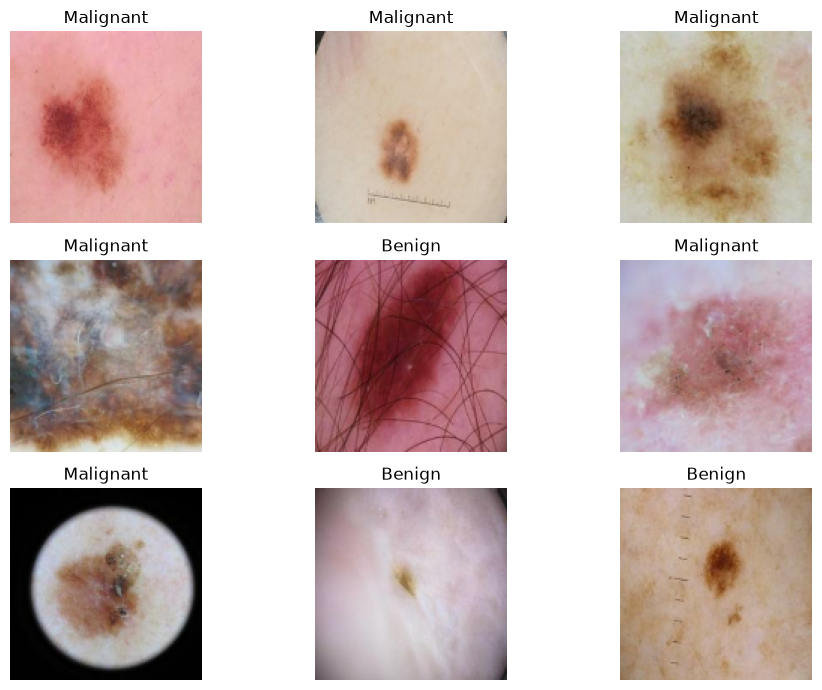

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        label_index = int(labels[i].numpy().item())
        plt.title(train_ds.class_names[label_index])

        plt.axis("off")

plt.tight_layout()
plt.show()

<div style="
background:#ECFDF5;
border-left:5px solid #27AE60;
border-radius:11px;
padding:14px 17px;
margin:15px 0;
">

<p style="color:#285943;line-height:1.8;margin:0;">
<b style="color:#1F8A50;">Visual check:</b>
The training samples contain both Benign and Malignant skin images,
and the labels are being read correctly from the folder structure.

The visual differences are not always obvious at a glance,
which makes this a meaningful task for a CNN:
the model must learn useful patterns from the image pixels rather than rely on
a simple manually defined rule.
</p>

</div>

<div style="
background:#FFF7E8;
border-left:5px solid #F2994A;
border-radius:11px;
padding:14px 17px;
margin:16px 0;
">

<p style="color:#5F4632;line-height:1.8;margin:0;">
<b style="color:#D97706;">One step before learning:</b>
The images arrive with pixel values between <b>0 and 255</b>.
A <b>Rescaling</b> layer will convert them to the
<b style="color:#2F80ED;">0–1 range</b> before they reach the convolution layers.

Keeping this transformation inside the model also makes the preprocessing
part of the complete CNN pipeline.
</p>

</div>

<div style="
background:linear-gradient(135deg,#F5F0FF 0%,#EEF7FF 100%);
border-left:6px solid #8B5CF6;
border-radius:14px;
padding:18px 21px;
margin:22px 0 16px 0;
">

<h3 style="color:#6D28D9;margin:0 0 9px 0;">
2.3 CNN From Scratch — From Pixels to Prediction
</h3>

<p style="color:#3F3A4A;line-height:1.9;margin:0;">
Now the pieces from Day 1 and today's pooling experiment come together.

The network will gradually move from raw pixels to learned visual features,
compress those features with MaxPooling, and finally use them to make one
binary decision:
<b style="color:#E76F51;">Benign or Malignant.</b>
</p>

</div>

<div style="
background:#FFFFFF;
border:1px solid #DCE5F2;
border-radius:13px;
padding:15px 18px;
margin:14px 0;
text-align:center;
">

<span style="color:#2F80ED;font-weight:bold;">Image</span>
&nbsp; → &nbsp;
<span style="color:#8B5CF6;font-weight:bold;">Conv2D</span>
&nbsp; → &nbsp;
<span style="color:#27AE60;font-weight:bold;">MaxPooling</span>
&nbsp; → &nbsp;
<span style="color:#8B5CF6;font-weight:bold;">Conv2D</span>
&nbsp; → &nbsp;
<span style="color:#27AE60;font-weight:bold;">MaxPooling</span>
&nbsp; → &nbsp;
<span style="color:#F2994A;font-weight:bold;">Flatten</span>
&nbsp; → &nbsp;
<span style="color:#E76F51;font-weight:bold;">Dense</span>
&nbsp; → &nbsp;
<span style="color:#A23E72;font-weight:bold;">Prediction</span>

</div>

<div style="
background:#FFF7E8;
border-left:5px solid #F2994A;
border-radius:11px;
padding:14px 17px;
margin:16px 0;
">

<p style="color:#5F4632;line-height:1.85;margin:0;">
<b style="color:#D97706;">Why this architecture?</b>

The first convolution layer starts with
<b style="color:#8B5CF6;">32 filters</b>
to learn simple visual patterns from the skin images.

After MaxPooling reduces the feature-map size, a second convolution layer uses
<b style="color:#8B5CF6;">64 filters</b>
to learn richer combinations of those patterns.

Finally, the extracted feature maps are flattened and passed to a Dense layer
that makes the classification decision.
</p>

</div>

In [14]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Rescaling,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

cnn_model = Sequential([
    Rescaling(1./255, input_shape=(128, 128, 3)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

cnn_model.summary()

c:\Users\Bisan\miniconda3\envs\binx-ai\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,921 (14.14 MB)

 Trainable params: 3,705,921 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

<div style="
background:#EEF7FF;
border-left:5px solid #2F80ED;
border-radius:11px;
padding:14px 17px;
margin:15px 0;
">

<p style="color:#374151;line-height:1.85;margin:0;">
<b style="color:#1D4ED8;">Why one output neuron?</b>

This dataset contains only two classes:
<b style="color:#27AE60;">Benign</b> and
<b style="color:#E76F51;">Malignant</b>.

Because this is a <b>binary classification</b> problem, the output layer uses
<b style="color:#A23E72;">one neuron with sigmoid activation</b>.

Sigmoid produces a value between 0 and 1, which can be interpreted as the
model's probability for the positive class.
</p>

</div>

In [19]:
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


<div style="
background:#F0FDF4;
border-left:5px solid #27AE60;
border-radius:11px;
padding:14px 17px;
margin:15px 0;
">

<p style="color:#285943;line-height:1.85;margin:0;">
<b style="color:#1F8A50;">Training setup:</b>

<b>Adam</b> will update the network weights during training, while
<b>binary cross-entropy</b> measures the error between the predicted probability
and the true binary label.

Accuracy will provide the first overall measure of how often the CNN predicts
the correct class.
</p>

</div>

<div style="
background:linear-gradient(135deg,#EEF7FF 0%,#F0FDF4 100%);
border-left:6px solid #27AE60;
border-radius:14px;
padding:17px 20px;
margin:21px 0 15px 0;
">

<h3 style="color:#18794E;margin:0 0 9px 0;">
2.4 Training — Let the CNN Learn From Scratch
</h3>

<p style="color:#374151;line-height:1.85;margin:0;">
The architecture is ready, but its filters still begin with random weights.

During training, the CNN will repeatedly see the melanoma images,
make predictions, calculate its error, and update those filters.

The important part is not only whether
<b style="color:#27AE60;">training accuracy increases</b>,
but whether
<b style="color:#2F80ED;">validation performance follows it</b>.
A growing gap between them may indicate overfitting.
</p>

</div>

In [20]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [21]:
EPOCHS = 10

history_baseline = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


c:\Users\Bisan\miniconda3\envs\binx-ai\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


297/297 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.7851 - loss: 0.4554 - val_accuracy: 0.8034 - val_loss: 0.3884
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 48s 162ms/step - accuracy: 0.8280 - loss: 0.3824 - val_accuracy: 0.8269 - val_loss: 0.3672
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 40s 136ms/step - accuracy: 0.8411 - loss: 0.3529 - val_accuracy: 0.8404 - val_loss: 0.3540
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 39s 131ms/step - accuracy: 0.8509 - loss: 0.3332 - val_accuracy: 0.8421 - val_loss: 0.3391
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 37s 123ms/step - accuracy: 0.8609 - loss: 0.3160 - val_accuracy: 0.8509 - val_loss: 0.3244
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 37s 123ms/step - accuracy: 0.8688 - loss: 0.3061 - val_accuracy: 0.8472 - val_loss: 0.3450
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 30s 100ms/step - accuracy: 0.8737 - loss: 0.2995 - val_accuracy: 0.8434 - val_loss: 0.3486
Epoch 8/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 27s 91ms/step - accuracy: 0.8753 - loss: 0.2874 - val_

In [63]:
baseline_history = history_baseline.history
epochs = range(1, len(baseline_history["accuracy"]) + 1)

<div style="
background:linear-gradient(135deg,#EEF7FF 0%,#F0FDF4 100%);
border-left:6px solid #2F80ED;
border-radius:14px;
padding:17px 20px;
margin:21px 0 15px 0;
">

<h3 style="color:#1D4ED8;margin:0 0 9px 0;">
2.5 Learning Curves — Did the CNN Actually Learn?
</h3>

<p style="color:#374151;line-height:1.85;margin:0;">
A final accuracy value tells only part of the story.

To understand how the CNN learned across the 10 epochs,
I will compare the
<b style="color:#2F80ED;">training</b> and
<b style="color:#27AE60;">validation</b>
curves for both accuracy and loss.

This helps reveal whether the model is learning useful patterns
or simply becoming better at memorizing its training images.
</p>

</div>

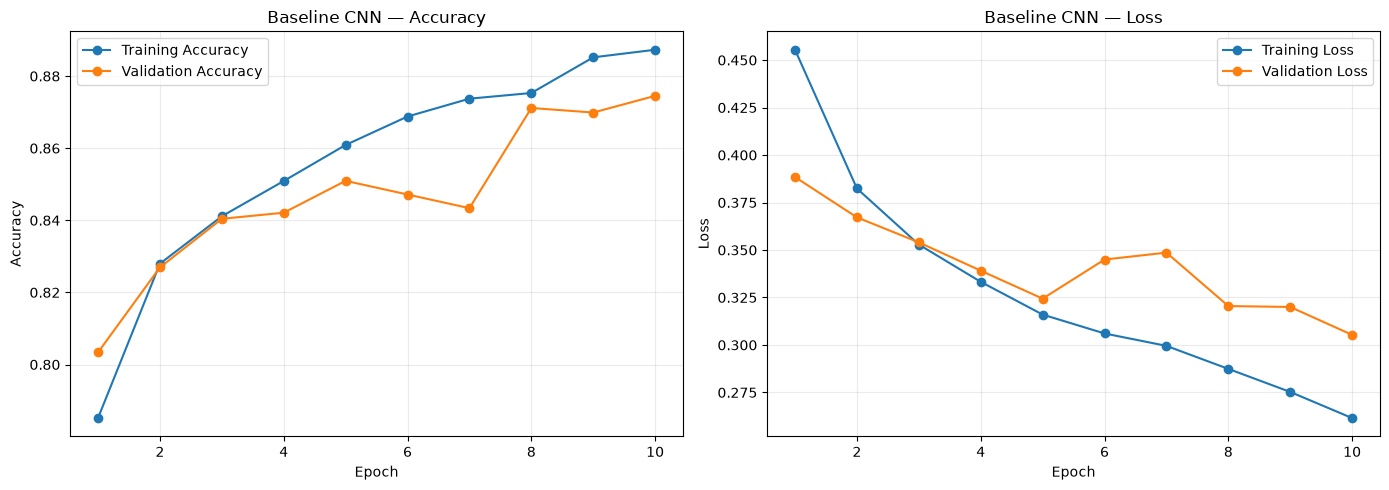

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(
    epochs,
    baseline_history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

axes[0].plot(
    epochs,
    baseline_history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

axes[0].set_title("Baseline CNN — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.25)

# Loss
axes[1].plot(
    epochs,
    baseline_history["loss"],
    marker="o",
    label="Training Loss"
)

axes[1].plot(
    epochs,
    baseline_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

axes[1].set_title("Baseline CNN — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

<div style="
background:#ECFDF5;
border-left:5px solid #27AE60;
border-radius:12px;
padding:15px 18px;
margin:16px 0;
">

<p style="color:#285943;line-height:1.9;margin:0;">
<b style="color:#1F8A50;font-size:16px;">
What happened during training?
</b>


The CNN clearly learned useful visual patterns.
Training accuracy increased from about
<b>78.5%</b> to <b>88.7%</b>,
while validation accuracy reached
<b style="color:#1F8A50;">87.5%</b> by the final epoch.

More importantly, the two accuracy curves remained relatively close.
Validation loss showed a small increase around epochs 6–7,
but later recovered and reached its lowest value,
<b>0.3053</b>, at epoch 10.

So the baseline CNN shows
<b style="color:#2F80ED;">good generalization so far</b>,
with only a small final gap between training and validation accuracy.
There is no strong evidence of severe overfitting within these 10 epochs.
</p>

</div>

In [25]:
baseline_train_accuracy = baseline_history["accuracy"][-1]
baseline_val_accuracy = baseline_history["val_accuracy"][-1]
baseline_val_loss = baseline_history["val_loss"][-1]

print(f"Final Training Accuracy:   {baseline_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {baseline_val_accuracy:.4f}")
print(f"Final Validation Loss:     {baseline_val_loss:.4f}")

Final Training Accuracy:   0.8873
Final Validation Accuracy: 0.8745
Final Validation Loss:     0.3053


<div style="
background:#FFF7E8;
border-left:5px solid #F2994A;
border-radius:11px;
padding:13px 16px;
margin:16px 0;
">

<b style="color:#D97706;">Hands-On 2 — Add Data Augmentation</b><br>
<span style="color:#5F4632;">
Apply image augmentation and compare its validation behavior with the baseline CNN.
</span>

</div>

<div style="
background:linear-gradient(135deg,#FFF7E8 0%,#FFF1E6 100%);
border-left:6px solid #F2994A;
border-radius:14px;
padding:18px 21px;
margin:22px 0;
">

<h2 style="color:#D97706;margin:0 0 9px 0;">
3. Data Augmentation — What If Every Image Looks a Little Different?
</h2>

<p style="color:#4B4238;line-height:1.9;margin:0;">

The first CNN performed well, but it repeatedly saw the
<b>same training images</b> across epochs.

Instead of giving the network more collected data, I can make the existing
training images slightly different each time they are seen.

<br><br>

With <b style="color:#E76F51;">Data Augmentation</b>,
random transformations such as flips, rotations, and zooms create new variations
during training — making memorization harder and encouraging the CNN to learn
more general visual patterns.

</p>

</div>

<div style="
background:#EEF7FF;
border-left:5px solid #2F80ED;
border-radius:11px;
padding:14px 17px;
margin:15px 0;
">

<p style="color:#374151;line-height:1.85;margin:0;">
<b style="color:#1D4ED8;">The experiment:</b>
I will keep the CNN architecture and training setup consistent with the baseline,
but add random transformations to the training images.

This makes the comparison more meaningful:
the main change between the two experiments is
<b style="color:#E76F51;">how the model sees its training data.</b>
</p>

</div>

In [26]:
from tensorflow.keras.layers import (
    RandomFlip,
    RandomRotation,
    RandomZoom
)

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

<div style="
background:linear-gradient(135deg,#EEF7FF 0%,#F0FDF4 100%);
border-left:6px solid #27AE60;
border-radius:14px;
padding:17px 20px;
margin:20px 0;
">

<h3 style="color:#18794E;margin:0 0 9px 0;">
3.1 One Image — Many Training Experiences
</h3>

<p style="color:#374151;line-height:1.9;margin:0;">
Data augmentation does not permanently create new image files.

Instead, every time an image passes through the augmentation layers during training,
it may appear slightly different.

<br><br>

To make this visible, I will take
<b style="color:#2F80ED;">one training image</b>
and generate several random versions of it using the same transformations
that will later be applied to the CNN.
</p>

</div>

In [28]:
class_names = ["Benign", "Malignant"]

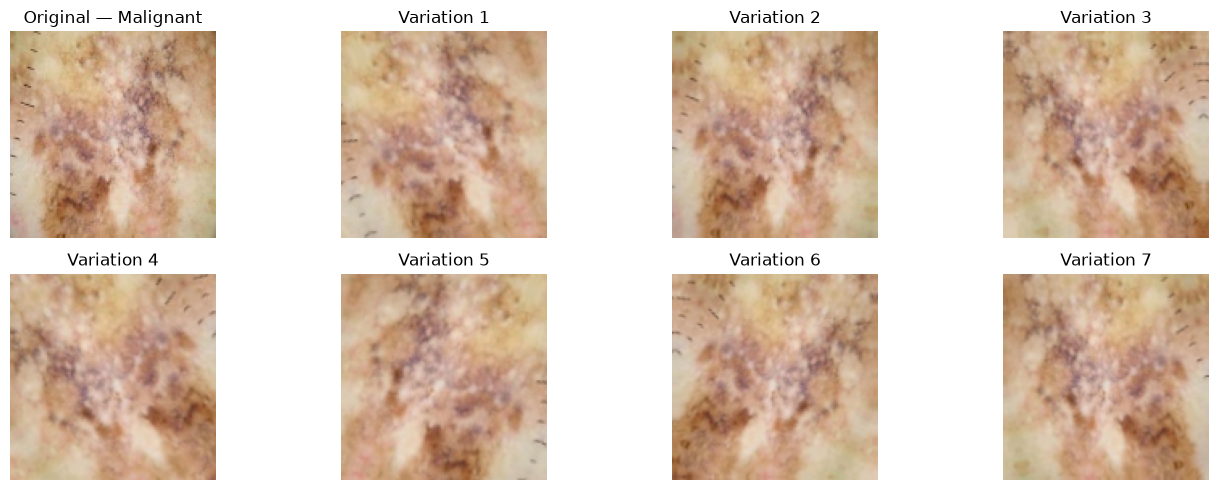

In [29]:
for images, labels in train_ds.take(1):
    sample_image = images[0]
    sample_label = int(labels[0].numpy().item())

plt.figure(figsize=(14, 5))

# Original image
plt.subplot(2, 4, 1)
plt.imshow(sample_image.numpy().astype("uint8"))
plt.title(f"Original — {class_names[sample_label]}")
plt.axis("off")

# Augmented versions
for i in range(1, 8):
    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, 0),
        training=True
    )

    plt.subplot(2, 4, i + 1)
    plt.imshow(
        tf.cast(augmented_image[0], tf.uint8).numpy()
    )
    plt.title(f"Variation {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

<div style="
background:#ECFDF5;
border-left:5px solid #27AE60;
border-radius:11px;
padding:14px 17px;
margin:15px 0;
">

<p style="color:#285943;line-height:1.9;margin:0;">
<b style="color:#1F8A50;">What changed?</b>

The medical image still represents the
<b>same class</b>, but its orientation, rotation, and visible scale can vary
slightly each time it is processed.

<br><br>

This means the CNN cannot depend as heavily on the exact position or appearance
of one training image. It must learn
<b style="color:#18794E;">more stable visual features</b>
that remain useful across these variations.
</p>

</div>

In [32]:
augmented_model = Sequential([
    tf.keras.Input(shape=(128, 128, 3)),

    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),

    Rescaling(1./255),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

augmented_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,921 (14.14 MB)

 Trainable params: 3,705,921 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
augmented_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

<div style="
background:#FFF7E8;
border-left:5px solid #F2994A;
border-radius:11px;
padding:14px 17px;
margin:16px 0;
">

<p style="color:#5F4632;line-height:1.85;margin:0;">
<b style="color:#D97706;">A fair comparison:</b>

The CNN architecture and training setup will remain consistent with the baseline.

The main difference is that this model receives
<b style="color:#E76F51;">randomly augmented images</b>
before feature extraction begins.

This allows me to test whether image variation can improve generalization
without changing the core classifier.
</p>

</div>

<div style="
background:linear-gradient(135deg,#F5F0FF 0%,#EEF7FF 100%);
border-left:6px solid #8B5CF6;
border-radius:14px;
padding:17px 20px;
margin:20px 0;
">

<h3 style="color:#6D28D9;margin:0 0 9px 0;">
3.2 Training With Augmentation — Same CNN, Harder Images
</h3>

<p style="color:#3F3A4A;line-height:1.85;margin:0;">
The augmented CNN will now train for the same
<b>10 epochs</b> as the baseline.

Because the training images are randomly transformed,
the task is intentionally more challenging.
The question is whether this added variation helps the model perform
more consistently on unseen validation images.
</p>

</div>

In [38]:
history_augmented = augmented_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


c:\Users\Bisan\miniconda3\envs\binx-ai\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


297/297 ━━━━━━━━━━━━━━━━━━━━ 68s 225ms/step - accuracy: 0.7781 - loss: 0.4636 - val_accuracy: 0.8084 - val_loss: 0.4418
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 74s 248ms/step - accuracy: 0.8223 - loss: 0.3908 - val_accuracy: 0.8366 - val_loss: 0.3687
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 49s 162ms/step - accuracy: 0.8408 - loss: 0.3617 - val_accuracy: 0.8375 - val_loss: 0.3593
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 52s 175ms/step - accuracy: 0.8429 - loss: 0.3545 - val_accuracy: 0.8526 - val_loss: 0.3298
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 45s 152ms/step - accuracy: 0.8507 - loss: 0.3410 - val_accuracy: 0.8505 - val_loss: 0.3282
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 52s 173ms/step - accuracy: 0.8546 - loss: 0.3383 - val_accuracy: 0.8387 - val_loss: 0.3513
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 51s 171ms/step - accuracy: 0.8508 - loss: 0.3370 - val_accuracy: 0.8568 - val_loss: 0.3244
Epoch 8/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 51s 172ms/step - accuracy: 0.8568 - loss: 0.3299 - val

In [39]:
augmented_history = history_augmented.history
epochs = range(1, len(augmented_history["accuracy"]) + 1)

augmented_train_accuracy = augmented_history["accuracy"][-1]
augmented_val_accuracy = augmented_history["val_accuracy"][-1]
augmented_val_loss = augmented_history["val_loss"][-1]

print(f"Final Training Accuracy:   {augmented_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {augmented_val_accuracy:.4f}")
print(f"Final Validation Loss:     {augmented_val_loss:.4f}")

Final Training Accuracy:   0.8617
Final Validation Accuracy: 0.8615
Final Validation Loss:     0.3184


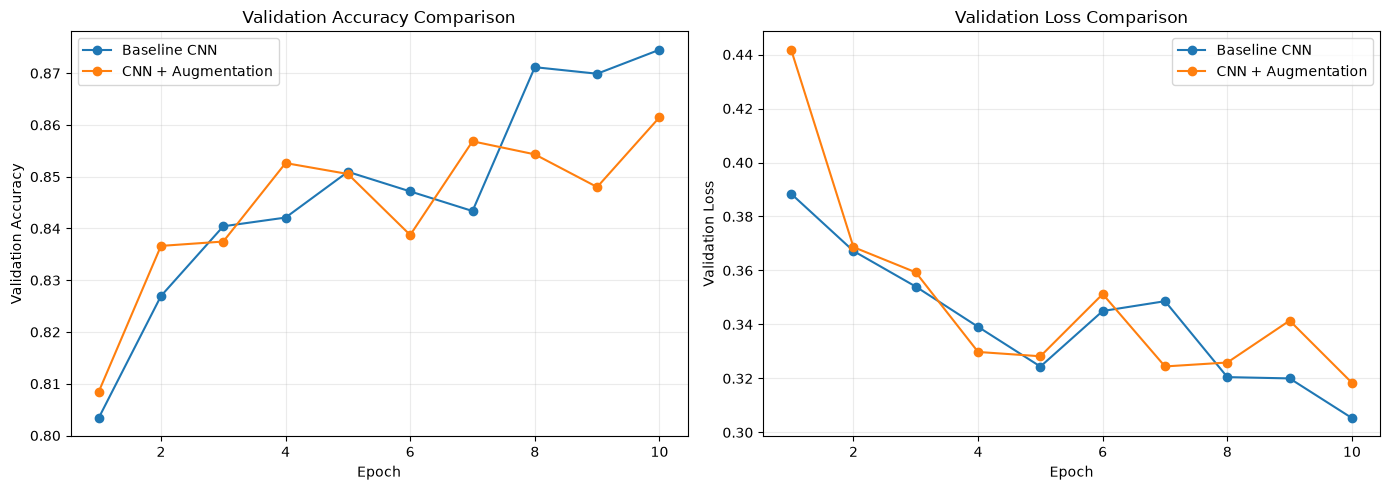

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation Accuracy
axes[0].plot(
    epochs,
    baseline_history["val_accuracy"],
    marker="o",
    label="Baseline CNN"
)

axes[0].plot(
    epochs,
    augmented_history["val_accuracy"],
    marker="o",
    label="CNN + Augmentation"
)

axes[0].set_title("Validation Accuracy Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.25)

# Validation Loss
axes[1].plot(
    epochs,
    baseline_history["val_loss"],
    marker="o",
    label="Baseline CNN"
)

axes[1].plot(
    epochs,
    augmented_history["val_loss"],
    marker="o",
    label="CNN + Augmentation"
)

axes[1].set_title("Validation Loss Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

<div style="
background:#ECFDF5;
border-left:5px solid #27AE60;
border-radius:12px;
padding:15px 18px;
margin:16px 0;
">

<p style="color:#285943;line-height:1.9;margin:0;">

<b style="color:#1F8A50;font-size:16px;">
What did augmentation change?
</b>

The augmented CNN reached a final training accuracy of
<b>86.17%</b> and a validation accuracy of
<b>86.15%</b>.

The almost identical training and validation results show that the model
generalized consistently and did not develop a noticeable training-validation gap.

However, the baseline CNN still achieved a slightly higher final validation accuracy:
<b style="color:#2F80ED;">87.45%</b> compared with
<b style="color:#E76F51;">86.15%</b> after augmentation.

So, in this experiment, augmentation improved the balance between training and
validation behavior, but it did not improve the final validation accuracy within
the same 10 epochs.

</p>

</div>

<div style="
background:#EEF7FF;
border-left:5px solid #2F80ED;
border-radius:11px;
padding:13px 16px;
margin:16px 0;
">

<b style="color:#1D4ED8;">Hands-On 3 — Transfer Learning with MobileNetV2</b><br>
<span style="color:#374151;">
Train a classifier using a frozen pre-trained MobileNetV2 model and compare its performance with the CNN approaches.
</span>

</div>

<div style="
background:linear-gradient(135deg,#F6F0FA 0%,#EEF7FF 100%);
border-left:6px solid #8B5CF6;
border-radius:14px;
padding:18px 21px;
margin:22px 0;
">

<h2 style="color:#5B2A86;margin:0 0 9px 0;">
4. Transfer Learning — What If the CNN Already Knows How to See?
</h2>

<p style="color:#374151;line-height:1.9;margin:0;">

The previous two CNNs started with
<b style="color:#E76F51;">randomly initialized weights</b>
and had to learn visual features directly from the melanoma dataset.

<br><br>

But training every visual feature from scratch is not always necessary.

With
<b style="color:#8B5CF6;">Transfer Learning</b>,
I can start with a network that has already learned useful visual patterns
from a much larger image dataset.

For this experiment, I will use
<b style="color:#2F80ED;">MobileNetV2</b>
pre-trained on ImageNet and adapt its learned features to the
Benign vs Malignant classification task.

</p>

</div>

<div style="
background:#FFF7E8;
border-left:5px solid #F2994A;
border-radius:11px;
padding:14px 17px;
margin:15px 0;
">

<p style="color:#5F4632;line-height:1.85;margin:0;">

<b style="color:#D97706;">The strategy:</b>

Instead of replacing what MobileNetV2 has already learned,
I will first
<b style="color:#5B2A86;">freeze its pre-trained layers</b>.

Their weights will remain unchanged during training.

I only need to add a new classification head that learns how to use those
existing visual features for my two melanoma classes.

</p>

</div>

In [43]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [44]:
print("Base model:", base_model.name)
print("Total layers:", len(base_model.layers))
print("Trainable:", base_model.trainable)

Base model: mobilenetv2_1.00_128
Total layers: 154
Trainable: False


<div style="
background:#EEF7FF;
border-left:5px solid #2F80ED;
border-radius:11px;
padding:14px 17px;
margin:15px 0;
">

<p style="color:#374151;line-height:1.85;margin:0;">

<b style="color:#1D4ED8;">How will the transfer model work?</b>

The input images will first be scaled to the range expected by
<b style="color:#5B2A86;">MobileNetV2</b>.

The frozen base model will then extract visual features using its pre-trained weights.

Instead of flattening a large feature map,
<b style="color:#27AE60;">GlobalAveragePooling2D</b>
will summarize each feature channel into one value.

Finally, a new
<b style="color:#E76F51;">sigmoid output neuron</b>
will learn the Benign vs Malignant decision.

</p>

</div>

In [45]:
transfer_model = Sequential([
    tf.keras.Input(shape=(128, 128, 3)),

    Rescaling(1./127.5, offset=-1),

    base_model,

    GlobalAveragePooling2D(),

    Dense(1, activation="sigmoid")
])

transfer_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

<div style="
background:#ECFDF5;
border-left:5px solid #27AE60;
border-radius:11px;
padding:14px 17px;
margin:15px 0;
">

<p style="color:#285943;line-height:1.85;margin:0;">

<b style="color:#1F8A50;">What is actually learning?</b>

Most of the network belongs to the frozen
<b style="color:#5B2A86;">MobileNetV2 base</b>,
so its pre-trained visual features will not be updated.

Only the new classification head is trainable.

This is the key idea behind the first stage of transfer learning:
<b style="color:#18794E;">reuse existing visual knowledge and learn only the new task.</b>

</p>

</div>

In [46]:
transfer_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

<div style="
background:linear-gradient(135deg,#F6F0FA 0%,#EEF7FF 100%);
border-left:6px solid #8B5CF6;
border-radius:14px;
padding:17px 20px;
margin:20px 0;
">

<h3 style="color:#6D28D9;margin:0 0 9px 0;">
4.1 Frozen Transfer Learning — Can Previous Knowledge Help?
</h3>

<p style="color:#374151;line-height:1.85;margin:0;">

MobileNetV2 will now process the melanoma images using its frozen
pre-trained features, while only the new classification layer learns.

Unlike the previous CNNs, this model does not need to discover every
visual pattern from scratch.

The experiment will show whether that previous knowledge can provide
stronger validation performance on this dataset.

</p>

</div>

In [47]:
history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 115s 335ms/step - accuracy: 0.8208 - loss: 0.3917 - val_accuracy: 0.8539 - val_loss: 0.3293
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 66s 222ms/step - accuracy: 0.8664 - loss: 0.3091 - val_accuracy: 0.8598 - val_loss: 0.3132
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 70s 235ms/step - accuracy: 0.8773 - loss: 0.2883 - val_accuracy: 0.8615 - val_loss: 0.3081
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 75s 252ms/step - accuracy: 0.8872 - loss: 0.2724 - val_accuracy: 0.8636 - val_loss: 0.3041
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 69s 234ms/step - accuracy: 0.8880 - loss: 0.2677 - val_accuracy: 0.8661 - val_loss: 0.2986
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 89s 301ms/step - accuracy: 0.8917 - loss: 0.2581 - val_accuracy: 0.8606 - val_loss: 0.3104
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 103s 347ms/step - accuracy: 0.8952 - loss: 0.2527 - val_accuracy: 0.8678 - val_loss: 0.2993
Epoch 8/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 92s 309ms/step - accuracy: 0.8994 - loss:

In [48]:
transfer_history = history_transfer.history

transfer_train_accuracy = transfer_history["accuracy"][-1]
transfer_val_accuracy = transfer_history["val_accuracy"][-1]
transfer_val_loss = transfer_history["val_loss"][-1]

print(f"Final Training Accuracy:   {transfer_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {transfer_val_accuracy:.4f}")
print(f"Final Validation Loss:     {transfer_val_loss:.4f}")

Final Training Accuracy:   0.9031
Final Validation Accuracy: 0.8724
Final Validation Loss:     0.3003


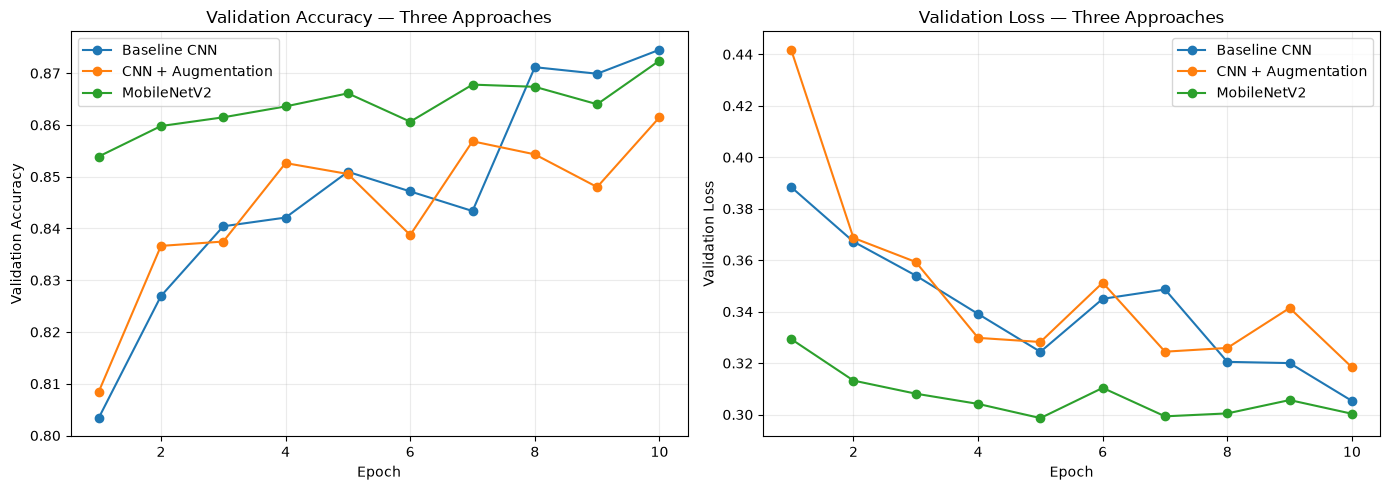

In [49]:
transfer_epochs = range(1, len(transfer_history["accuracy"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation Accuracy
axes[0].plot(
    epochs,
    baseline_history["val_accuracy"],
    marker="o",
    label="Baseline CNN"
)

axes[0].plot(
    epochs,
    augmented_history["val_accuracy"],
    marker="o",
    label="CNN + Augmentation"
)

axes[0].plot(
    transfer_epochs,
    transfer_history["val_accuracy"],
    marker="o",
    label="MobileNetV2"
)

axes[0].set_title("Validation Accuracy — Three Approaches")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.25)

# Validation Loss
axes[1].plot(
    epochs,
    baseline_history["val_loss"],
    marker="o",
    label="Baseline CNN"
)

axes[1].plot(
    epochs,
    augmented_history["val_loss"],
    marker="o",
    label="CNN + Augmentation"
)

axes[1].plot(
    transfer_epochs,
    transfer_history["val_loss"],
    marker="o",
    label="MobileNetV2"
)

axes[1].set_title("Validation Loss — Three Approaches")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

<div style="
background:#EEF7FF;
border-left:5px solid #2F80ED;
border-radius:12px;
padding:15px 18px;
margin:16px 0;
">

<p style="color:#374151;line-height:1.9;margin:0;">

<b style="color:#1D4ED8;font-size:16px;">
What did Transfer Learning change?
</b>

The frozen MobileNetV2 model reached
<b style="color:#5B2A86;">90.31% training accuracy</b>
and
<b style="color:#27AE60;">87.24% validation accuracy</b>.

Its validation performance was very close to the baseline CNN,
which achieved <b>87.45%</b>, while the augmented CNN reached
<b>86.15%</b>.

Although MobileNetV2 did not achieve the highest final validation accuracy,
it produced the
<b style="color:#27AE60;">lowest final validation loss (0.3003)</b>
among the three approaches.

This shows that pre-trained visual features transferred effectively to the
melanoma classification task, even without training the MobileNetV2 base
from scratch.

</p>

</div>

<div style="
background:linear-gradient(135deg,#FFF7E8 0%,#F6F0FA 100%);
border-left:6px solid #F2994A;
border-radius:14px;
padding:18px 20px;
margin:22px 0;
">

<h3 style="color:#D97706;margin:0 0 10px 0;">
4.2 Fine-Tuning — Can MobileNetV2 Adapt to Melanoma?
</h3>

<p style="color:#374151;line-height:1.9;margin:0;">

So far, MobileNetV2 has been used as a
<b style="color:#5B2A86;">frozen feature extractor</b>.

Its pre-trained features worked well, but they were originally learned from
ImageNet rather than melanoma images

Now, instead of retraining the entire network, I will unfreeze only a
<b style="color:#E76F51;">small group of the final layers</b>.

This allows the higher-level visual features to adapt to the current task
while preserving most of the useful pre-trained knowledge.

</p>

</div>

In [50]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

<div style="
background:#EEF7FF;
border-left:5px solid #2F80ED;
border-radius:11px;
padding:14px 17px;
margin:15px 0;
">

<p style="color:#374151;line-height:1.85;margin:0;">

<b style="color:#1D4ED8;">Why such a small learning rate?</b><br><br>

Fine-tuning uses a very small learning rate
(<b>1e-5</b>) because the pre-trained weights are already useful.

Large updates could destroy that learned knowledge, while small updates allow
the final layers to adapt gradually to melanoma images.

</p>

</div>

In [62]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [51]:
trainable_layers = sum(
    layer.trainable for layer in base_model.layers
)

print("Total MobileNetV2 layers:", len(base_model.layers))
print("Trainable layers:", trainable_layers)

Total MobileNetV2 layers: 154
Trainable layers: 13


In [64]:
history_finetune = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

Epoch 1/3


297/297 ━━━━━━━━━━━━━━━━━━━━ 93s 297ms/step - accuracy: 0.9026 - loss: 0.2353 - val_accuracy: 0.8695 - val_loss: 0.3110
Epoch 2/3
297/297 ━━━━━━━━━━━━━━━━━━━━ 102s 343ms/step - accuracy: 0.9226 - loss: 0.2001 - val_accuracy: 0.8716 - val_loss: 0.3131
Epoch 3/3
297/297 ━━━━━━━━━━━━━━━━━━━━ 92s 310ms/step - accuracy: 0.9348 - loss: 0.1729 - val_accuracy: 0.8703 - val_loss: 0.3124


In [65]:
finetune_history = history_finetune.history

finetune_train_accuracy = finetune_history["accuracy"][-1]
finetune_val_accuracy = finetune_history["val_accuracy"][-1]
finetune_val_loss = finetune_history["val_loss"][-1]

best_finetune_val_accuracy = max(finetune_history["val_accuracy"])
best_finetune_epoch = (
    finetune_history["val_accuracy"].index(best_finetune_val_accuracy) + 1
)

print(f"Final Training Accuracy:     {finetune_train_accuracy:.4f}")
print(f"Final Validation Accuracy:   {finetune_val_accuracy:.4f}")
print(f"Final Validation Loss:       {finetune_val_loss:.4f}")
print(f"Best Validation Accuracy:    {best_finetune_val_accuracy:.4f}")
print(f"Best Fine-Tuning Epoch:      {best_finetune_epoch}")

Final Training Accuracy:     0.9348
Final Validation Accuracy:   0.8703
Final Validation Loss:       0.3124
Best Validation Accuracy:    0.8716
Best Fine-Tuning Epoch:      2


<div style="
background:#FFF7E8;
border-left:5px solid #F2994A;
border-radius:12px;
padding:15px 18px;
margin:16px 0;
">

<p style="color:#5F4632;line-height:1.9;margin:0;">

<b style="color:#D97706;font-size:16px;">
Did Fine-Tuning Improve the Model?
</b>

Fine-tuning allowed the final MobileNetV2 layers to adapt to the melanoma dataset,
but it did not improve validation performance over the frozen model.

The best validation accuracy reached
<b style="color:#27AE60;">87.16%</b> at Epoch 2,
while the final validation accuracy was
<b style="color:#E76F51;">87.03%</b>.

The frozen MobileNetV2 had already achieved
<b style="color:#2F80ED;">87.24%</b> validation accuracy,
and the baseline CNN remained slightly higher at
<b style="color:#5B2A86;">87.45%</b>.

So, under the current fine-tuning settings,
updating the final pre-trained layers did not provide a clear advantage.

</p>

</div>

<div style="
background:#ECFDF5;
border-left:5px solid #27AE60;
border-radius:11px;
padding:13px 16px;
margin:16px 0;
">

<b style="color:#18794E;">Hands-On 4 — Compare the Approaches</b><br>
<span style="color:#285943;">
Evaluate the approaches on unseen test data and determine which performed best and why.
</span>

</div>

<div style="
background:linear-gradient(135deg,#ECFDF5 0%,#EEF7FF 100%);
border-left:6px solid #27AE60;
border-radius:14px;
padding:18px 21px;
margin:22px 0;
">

<h2 style="color:#18794E;margin:0 0 10px 0;">
5. Final Evaluation — Which Model Generalizes Best?
</h2>

<p style="color:#374151;line-height:1.9;margin:0;">

Training and validation results helped compare the experiments while they were
being developed.

Now it is time for the final check using the
<b style="color:#2F80ED;">test set</b>.

These images were kept separate from training and validation, so they provide
a better final estimate of how each model performs on unseen data.

</p>

</div>

In [66]:
baseline_test_loss, baseline_test_accuracy = cnn_model.evaluate(
    test_ds,
    verbose=0
)

augmented_test_loss, augmented_test_accuracy = augmented_model.evaluate(
    test_ds,
    verbose=0
)

finetuned_test_loss, finetuned_test_accuracy = transfer_model.evaluate(
    test_ds,
    verbose=0
)

print(f"Baseline CNN Test Accuracy:        {baseline_test_accuracy:.4f}")
print(f"CNN + Augmentation Test Accuracy:  {augmented_test_accuracy:.4f}")
print(f"Fine-Tuned MobileNetV2 Accuracy:   {finetuned_test_accuracy:.4f}")

Baseline CNN Test Accuracy:        0.9015
CNN + Augmentation Test Accuracy:  0.8685
Fine-Tuned MobileNetV2 Accuracy:   0.8800


In [67]:
import pandas as pd

final_results = pd.DataFrame({
    "Approach": [
        "Baseline CNN",
        "CNN + Augmentation",
        "Fine-Tuned MobileNetV2"
    ],
    "Test Accuracy": [
        baseline_test_accuracy,
        augmented_test_accuracy,
        finetuned_test_accuracy
    ],
    "Test Loss": [
        baseline_test_loss,
        augmented_test_loss,
        finetuned_test_loss
    ]
})

final_results["Test Accuracy"] = (
    final_results["Test Accuracy"] * 100
).round(2)

final_results["Test Loss"] = (
    final_results["Test Loss"]
).round(4)

final_results

,Approach,Test Accuracy,Test Loss
0,Baseline CNN,90.15,0.5452
1,CNN + Augmentation,86.85,0.3359
2,Fine-Tuned MobileNetV2,88.00,0.2904


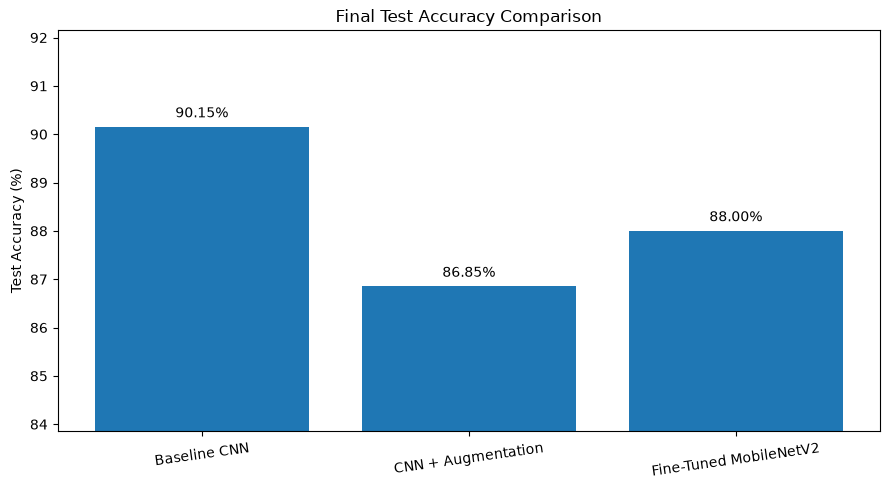

In [68]:
plt.figure(figsize=(9, 5))

plt.bar(
    final_results["Approach"],
    final_results["Test Accuracy"]
)

plt.title("Final Test Accuracy Comparison")
plt.ylabel("Test Accuracy (%)")
plt.ylim(
    final_results["Test Accuracy"].min() - 3,
    final_results["Test Accuracy"].max() + 2
)

plt.xticks(rotation=8)

for i, value in enumerate(final_results["Test Accuracy"]):
    plt.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

<div style="
background:linear-gradient(135deg,#ECFDF5 0%,#EEF7FF 100%);
border-left:6px solid #27AE60;
border-radius:14px;
padding:18px 21px;
margin:20px 0;
">

<h3 style="color:#18794E;margin:0 0 12px 0;">
Final Result — Simpler Won
</h3>

<p style="color:#374151;line-height:1.9;margin:0;">

The final test evaluation revealed a clear winner.

The
<b style="color:#5B2A86;">Baseline CNN</b>
achieved the highest test accuracy of
<b style="color:#27AE60;">90.15%</b>.

<br><br>

The
<b style="color:#E76F51;">CNN + Augmentation</b>
reached
<b>86.85%</b>,
while the
<b style="color:#2F80ED;">Fine-Tuned MobileNetV2</b>
achieved
<b>88.00%</b>.

<br><br>

Fine-tuning improved the transfer-learning model compared with its earlier result,
but it still did not outperform the simpler CNN trained from scratch.

This shows that a more complex approach does not automatically guarantee better
performance. For this dataset and the current training setup, the baseline CNN
generalized best to unseen test images.

</p>

</div>

<div style="
background:#FFF7E8;
border-left:5px solid #F2994A;
border-radius:12px;
padding:16px 19px;
margin:18px 0;
">

<h3 style="color:#D97706;margin-top:0;">
Training Time — Was Transfer Learning Faster?
</h3>

<p style="color:#374151;line-height:1.9;margin-bottom:0;">

The epoch outputs also showed an interesting computational trade-off.

The baseline CNN required approximately
<b>5.9 minutes</b> for 10 epochs, while the augmented CNN required about
<b>9.1 minutes</b>.

The frozen MobileNetV2 experiment took approximately
<b style="color:#E76F51;">14.0 minutes</b> for the same 10 epochs,
followed by about <b>4.8 additional minutes</b> for fine-tuning.


Therefore, transfer learning was
<b style="color:#D97706;">not faster in this experiment</b>.

Although most MobileNetV2 weights were frozen, the deeper pre-trained network
still had to perform its forward computations for every image.

Combined with the final test results, the baseline CNN provided the best
balance of
<b style="color:#27AE60;">accuracy and computational cost</b>
under the current setup.

</p>

</div>

<div style="
background:#F6F0FA;
border-left:5px solid #8B5CF6;
border-radius:12px;
padding:16px 19px;
margin:18px 0;
">

<h3 style="color:#5B2A86;margin-top:0;">
Day 2 Takeaways
</h3>

<p style="color:#374151;line-height:1.9;margin-bottom:0;">

Today, I moved from individual convolution operations to complete image
classification models.

I used <b>pooling</b> to reduce feature maps, built a complete
<b>CNN from scratch</b>, tested <b>data augmentation</b>,
and reused pre-trained visual knowledge through
<b>MobileNetV2 transfer learning</b>.

I also explored both <b>freezing</b> and <b>fine-tuning</b>
pre-trained layers.

The most important result was that model complexity alone did not determine
performance. On the unseen test set, the simple baseline CNN achieved the
best result with <b style="color:#27AE60;">90.15% accuracy</b>.

</p>

</div>

<div style="
background:linear-gradient(135deg,#F6F0FA 0%,#EEF7FF 100%);
border-left:6px solid #8B5CF6;
border-radius:14px;
padding:17px 20px;
margin:20px 0;
">

<h3 style="color:#5B2A86;margin:0 0 10px 0;">
Stand-Up Update
</h3>

<p style="color:#374151;line-height:1.9;margin:0;">

Today, I built and evaluated a complete CNN for melanoma image classification.

I started with a baseline CNN, then tested
<b style="color:#D97706;">data augmentation</b>
and
<b style="color:#2F80ED;">MobileNetV2 transfer learning</b>,
including both frozen feature extraction and fine-tuning.

The baseline CNN achieved the best final test accuracy at
<b style="color:#27AE60;">90.15%</b>,
showing that the simpler model generalized best under the current setup.

</p>

</div>